Link to dataset used: https://www.kaggle.com/datasets/andrewsundberg/college-basketball-dataset?select=cbb.csv 

This project aims to use data from college basketball teams that made March Madness from 2013-2024 to make predictions about what factors affect a team's performance to help people fill out there March Madness brackets. 

In [1]:
# import libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import Functions as func
import numpy as np

https://chatgpt.com/s/t_69aaf50e151c8191ae4626fc116222bc was used to help with the cleaning process when I noticed missing values still in my training and test set

https://chatgpt.com/s/t_69b96659c220819196883395a5bf7121 was used to help get the models to run, I only standardized the xDF. 

- What features/columns had a relatively even or normal distribution? Which features/columns did not?

    - For our categorical variables, all of TEAM, CONF, and POSTSEASON did not have a normal distribution. For our numerical columns, every numerical feature had an apporximently normal distribution except G, BARTHAG, SEED, and YEAR. This is all accounnting for the dataset being cleaned to have only teams that made the NCAA tournament

- How did you handle missing values? Why did you do this method as opposed to others?

    - I handled the missing values in the POSTSEASON and SEED columns by dropping the teams that didn't make the postseason, in  other words, drop the rows that have POSTSEASON and SEED with missing values. This does remove a large chunk of the data, but it narrows the scope of our data to teams 2013-2024 that made the NCAA tournament, which is the scope of what I want to make predictions for. Imputing the missing columns wouldn't make sense for this dataset because we can't assign values to teams that didn't actually make March Madness. Keeping the missing values wouldn't make sense for my goal of wanting to make predictions for teams that only made March Madness

- How did you encode your categorical data? Why did you do this method as opposed to others?

    - I encoded my cateogrical data using both the one-hot encoding and labeling encoding methods. I used one-hot encoding to code the TEAMS variable because there is no inherent order to any of the teams besides there alphabetical order, but I was not wanting to write out 100+ team names as a stored list. I used label encoding for CONF and POSTSEASON columns because both have an inherent order and not a ton of different variables, you can order conferences alphabetically and postseason finish from 0-7 based on how they finished in March Madness, with 0 being getting out in the round of 68 while 7 being winning that national title. 

- How did you handle removing outliers? Why did you use this method as opposed to others?

    - I am choosing not to remove any outliers because I want to maximize the amount of data I have while also not removing any of the data because every team in my cleaned dataset made March Madness from 2013 to 2024. Teams inside this dataset already should be similar to each other in that they qualified for March Madness, I don't want to lose any teams that have made March Madness if I'm trying to make predictions for March Madness. Since March Madness is such an unpredictable tournament, my hope is that including outliers in this dataset like St. Peter's who made the Elite Eight in the 2022 tournament will capture the variance the tournament is. Making the best predictions we can while including all the outliers is the goal. 

- How did you normalize/standardize the data? Why did you use this method as opposed to others?

    - I choose to standardize the data. I used this method because the majority of numerical columns in this dataset follow a normal distribution, and using standardization is a great method to use when data follows a normal distribution. Normalization would have been fine to use as well, but I felt like standardization would better capture how variables are distributed in this dataset. I chose to not standardize the outcome variable of postseason performance because the classifer for our models needs discrete labels. 

- How did each model perform? Which performed the best?

    - All of my models did not perform great, but model evaluation should consider how hard it is to classify March Madness teams by their outcome in the tournament. F1 score balances how many positive and negative predicions (precision adn recall) we made correctly. Logistic regression and random forest model had the lowest F1 scores of the four models (0.1840 adn 0.2629 respectively). Gradient boosting and decision tree performed slightly better, but not by much having F1 scores of 0.2740 and 0.3031 respectively. Random forest was the only model with an accuracy above 50% at 53.77%. Random Forest also had the higest precison at 0.3357. Decision tree had the highest recall and F1 score. I would argue Random Forest was the best model because it had the highest accuracy and precision. In trying to classify which teams go far in March Madness, we care more about positive outcomes of the model predicts more than negative outcomes the model predicts. The Random Forest is also the only model where it's accurate at a rate slightly more than a coin flip. We ideally want to classify how far teams advance, not which teams don't advance.

- Did any models seem to have a relatively high amount of bias (underfitting)? Variance (overfitting)?

    - All our models have a little bias in that they are partial datasets, they only include teams that made March Madness, not all college basketball teams. Since the dataset includes data for every game played in a college basketball season, this includes games that teams played against non-tournament teams. All of our models seem to underfit our data because of how poorly they peformed. They all had precision, recall, and F1 scores between 0.25 and 0.50, indicating that our models did't understand the underlying pattern of the data, as they predicted teams either correctly or incorrectly advancing to a particular round in March Madness only 25-50% of the time. The dataset itself had a lot of variance. You have outlier teams that are bad metric wise with respect to other March Madness teams like the St.Peter's team that made the Elite Eight in 2022 and a great Purdue team in 2023 that lost in the first round all in the same dataset. There is a decent amount of variance in tourament outcomes that aren't always dependent on the strength of the team, making it harder for our models to understand the underlying patterns in the data. 

The original dataframe

In [2]:
masterDF = pd.read_csv("cbb.csv")
masterDF = masterDF.replace(r'^\s*$', np.nan, regex=True)
masterDF.head()

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017


In [3]:
masterDF.shape

(3885, 24)

In [4]:
masterDF.describe()

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
count,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,...,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,748.000000,3885.000000
mean,30.531532,16.075418,103.339743,103.341519,0.493928,49.935856,50.125946,18.551223,18.483115,29.267310,...,34.384813,34.645766,49.224402,49.388880,34.141133,34.319614,67.712227,-7.639967,8.798128,2018.403604
std,3.809623,6.506570,7.315009,6.490684,0.255374,3.079803,2.855079,2.145057,2.289045,4.201366,...,5.465945,6.337450,3.416380,3.290915,2.713812,2.406306,3.037251,6.826502,4.671615,3.583747
min,5.000000,0.000000,76.600000,84.000000,0.005000,39.200000,39.600000,11.900000,10.200000,14.400000,...,19.600000,16.200000,37.700000,37.700000,24.700000,26.100000,57.200000,-25.200000,1.000000,2013.000000
25%,29.000000,11.000000,98.300000,98.600000,0.281200,47.900000,48.200000,17.100000,16.900000,26.500000,...,30.500000,30.100000,46.900000,47.200000,32.300000,32.700000,65.700000,-12.600000,5.000000,2015.000000
50%,31.000000,16.000000,103.000000,103.500000,0.474000,49.900000,50.100000,18.500000,18.400000,29.300000,...,34.200000,34.000000,49.200000,49.400000,34.100000,34.300000,67.600000,-8.100000,9.000000,2018.000000
75%,33.000000,21.000000,108.100000,108.000000,0.716400,52.000000,52.000000,19.900000,19.900000,32.000000,...,38.000000,38.600000,51.400000,51.700000,35.900000,35.900000,69.700000,-3.000000,13.000000,2022.000000
max,40.000000,38.000000,129.100000,124.000000,0.984200,61.000000,60.100000,27.100000,28.500000,43.600000,...,58.600000,60.700000,64.000000,61.200000,44.100000,43.100000,83.400000,13.100000,16.000000,2024.000000


In [5]:
for aCol in masterDF:
    print(f"The amount of missing values in {aCol} is {masterDF[aCol].isna().sum()}")

The amount of missing values in TEAM is 0
The amount of missing values in CONF is 0
The amount of missing values in G is 0
The amount of missing values in W is 0
The amount of missing values in ADJOE is 0
The amount of missing values in ADJDE is 0
The amount of missing values in BARTHAG is 0
The amount of missing values in EFG_O is 0
The amount of missing values in EFG_D is 0
The amount of missing values in TOR is 0
The amount of missing values in TORD is 0
The amount of missing values in ORB is 0
The amount of missing values in DRB is 0
The amount of missing values in FTR is 0
The amount of missing values in FTRD is 0
The amount of missing values in 2P_O is 0
The amount of missing values in 2P_D is 0
The amount of missing values in 3P_O is 0
The amount of missing values in 3P_D is 0
The amount of missing values in ADJ_T is 0
The amount of missing values in WAB is 0
The amount of missing values in POSTSEASON is 3137
The amount of missing values in SEED is 3137
The amount of missing val

I am going to handle the missing column values of POSTSEASON and SEED by dropping the teams that didn't make the postseason, in other words, drop the empty columns. This does remove a large chunk of the data, but it narrows the scope of our data to teams 2013-2024 that made the NCAA tournament, which is the scope of what I want to make predictions for.

In [6]:
marchMadnessDF = masterDF.dropna().reset_index(drop=True)
marchMadnessDF.shape

(748, 24)

In [7]:
marchMadnessDF = marchMadnessDF.drop(["TEAM"], axis=1)
marchMadnessDF.shape

(748, 23)

In [8]:
marchMadnessDF.describe()

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
count,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,...,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000,748.000000
mean,33.224599,24.048128,111.432487,96.786765,0.793626,52.152406,47.841444,17.344118,18.854545,31.288636,...,35.468984,32.328342,51.459492,47.049465,35.609759,32.895053,67.508957,1.319158,8.798128,2018.363636
std,3.498760,4.392745,6.376648,5.310531,0.169739,2.699870,2.338690,1.935508,2.480541,4.224797,...,5.514367,5.829416,3.037116,2.904479,2.545127,2.050008,3.035539,4.837747,4.671615,3.576865
min,15.000000,12.000000,90.600000,84.000000,0.152200,44.600000,39.600000,12.400000,11.200000,17.700000,...,21.300000,16.200000,42.400000,37.700000,26.600000,26.100000,58.400000,-15.600000,1.000000,2013.000000
25%,32.000000,21.000000,107.200000,93.200000,0.742150,50.275000,46.400000,16.100000,17.100000,28.600000,...,31.475000,28.000000,49.500000,45.100000,33.900000,31.500000,65.400000,-1.200000,5.000000,2015.000000
50%,34.000000,24.000000,111.600000,96.300000,0.855050,52.000000,47.900000,17.200000,18.600000,31.350000,...,35.200000,32.000000,51.300000,47.100000,35.600000,32.800000,67.500000,1.700000,9.000000,2018.000000
75%,35.000000,27.000000,115.700000,100.325000,0.911150,54.000000,49.400000,18.525000,20.300000,34.100000,...,39.200000,35.800000,53.300000,49.100000,37.300000,34.225000,69.600000,4.300000,13.000000,2022.000000
max,40.000000,38.000000,129.100000,115.600000,0.984200,61.000000,55.700000,23.700000,28.500000,43.600000,...,55.500000,55.500000,64.000000,56.700000,43.700000,38.700000,77.300000,13.100000,16.000000,2024.000000


In [9]:
categoricalCol = ["CONF", "POSTSEASON"]

Bar Graphs of Categorical Columns

In [10]:
def makeFrequencyChart(aDF, aColName) : 
    aDF[aColName].value_counts().plot(kind='bar', figsize=(7,6))
    plt.xlabel(aColName, labelpad=14)
    plt.ylabel("Count", labelpad=14)
    plt.title(f"Count of {aColName} column")

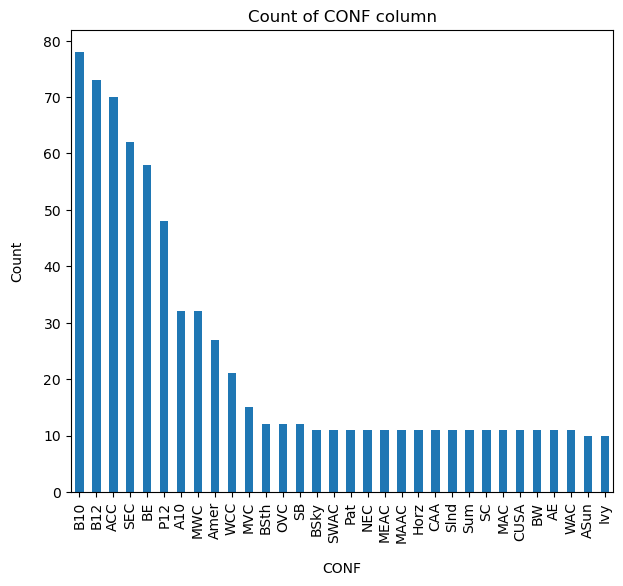

In [11]:
makeFrequencyChart(marchMadnessDF, "CONF")

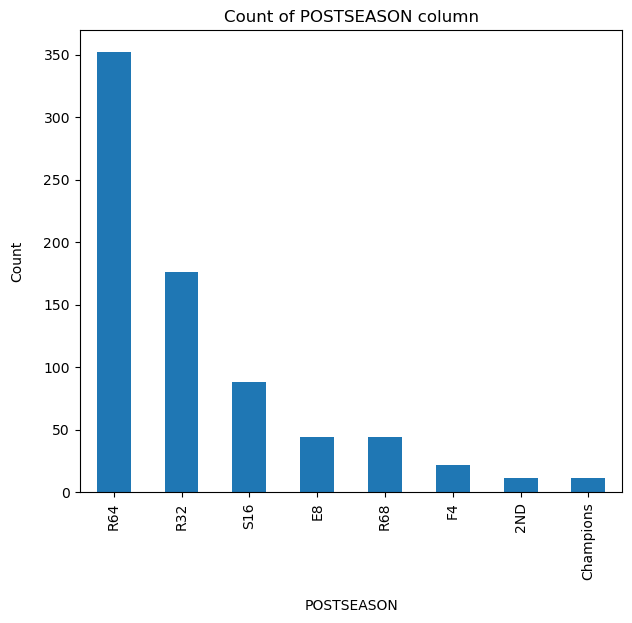

In [12]:
makeFrequencyChart(marchMadnessDF, "POSTSEASON")

Histogram distributions of numerical features

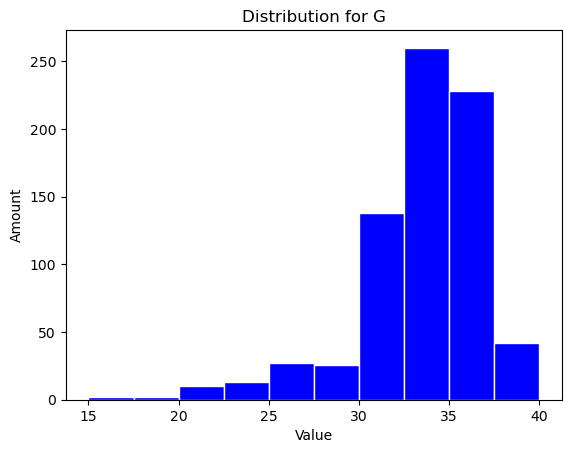

In [13]:
func.makeHist(marchMadnessDF, "G")

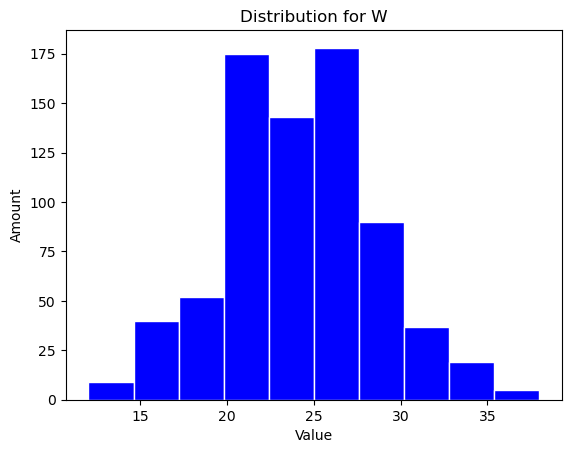

In [14]:
func.makeHist(marchMadnessDF, "W")

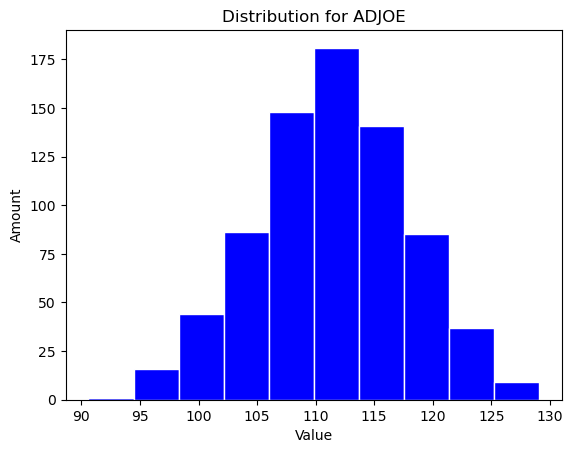

In [15]:
func.makeHist(marchMadnessDF, "ADJOE")

# ADJOE: Adjusted Offensive Efficiency (An estimate of the offensive efficiency (points scored per 100 possessions) 
# a team would have against the average Division I defense

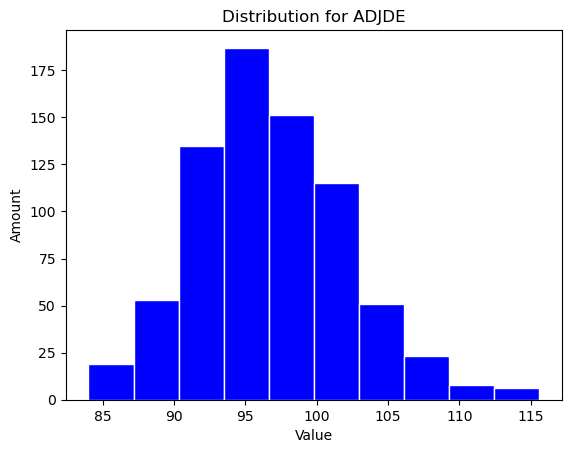

In [16]:
func.makeHist(marchMadnessDF, "ADJDE")

# ADJDE: Adjusted Defensive Efficiency (An estimate of the defensive efficiency (points allowed per 100 possessions) 
# a team would have against the average Division I offense)

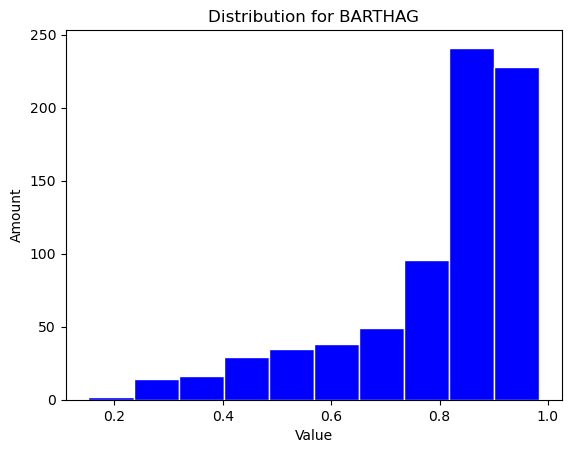

In [17]:
func.makeHist(marchMadnessDF, "BARTHAG")

# BARTHAG: Power Rating (Chance of beating an average Division I team)

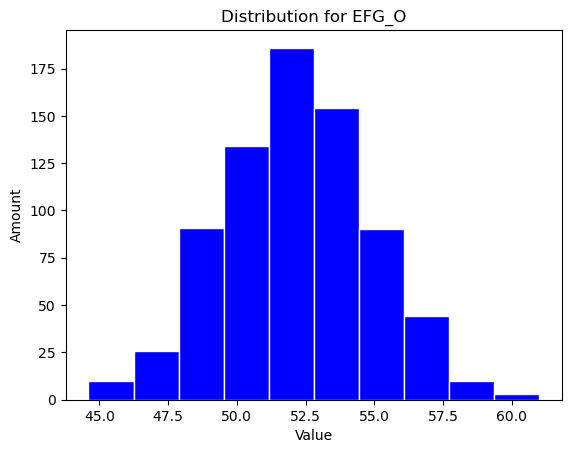

In [18]:
func.makeHist(marchMadnessDF, "EFG_O")
# EFG_O: Effective Field Goal Percentage Shot

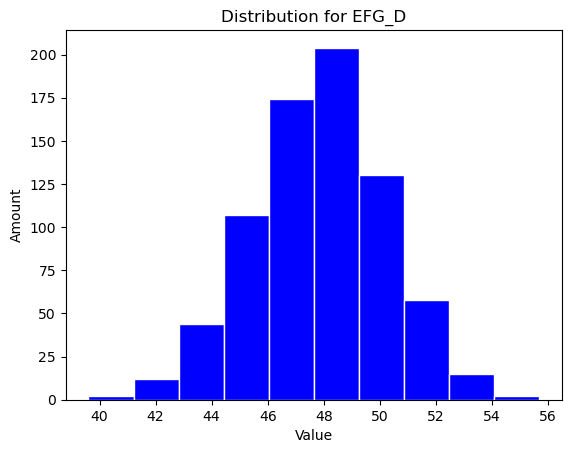

In [19]:
func.makeHist(marchMadnessDF, "EFG_D")
# EFG_O: Effective Field Goal Percentage Allowed

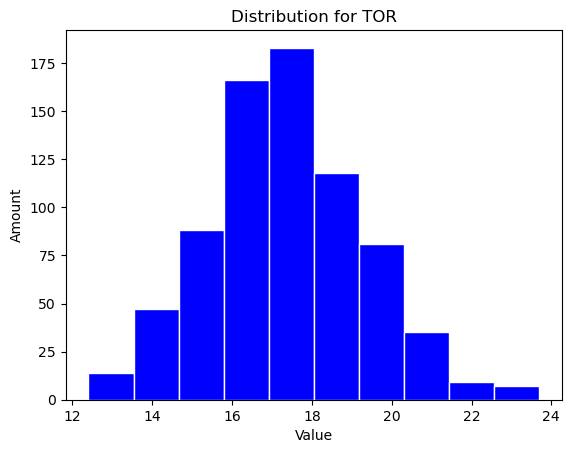

In [20]:
func.makeHist(marchMadnessDF, "TOR")
# TOR: Turnover Percentage Allowed (Turnover Rate)

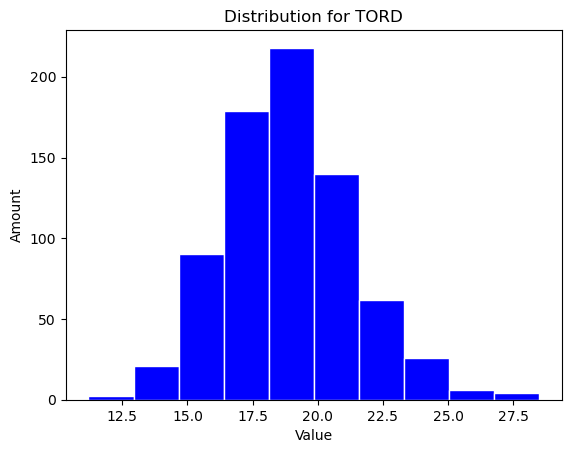

In [21]:
func.makeHist(marchMadnessDF, "TORD")
# TORD: Turnover Percentage Committed (Steal Rate)

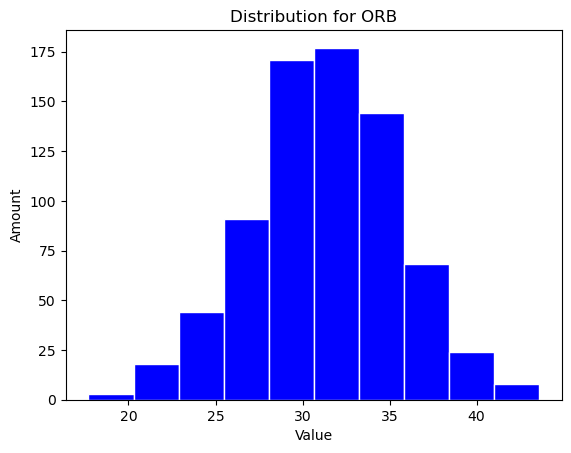

In [22]:
func.makeHist(marchMadnessDF, "ORB")
# ORB: Offensive Rebound Rate

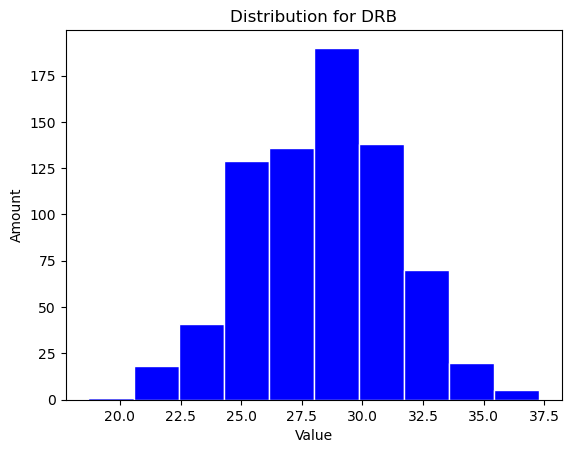

In [23]:
func.makeHist(marchMadnessDF, "DRB")
# DRB: Offensive Rebound Rate Allowed

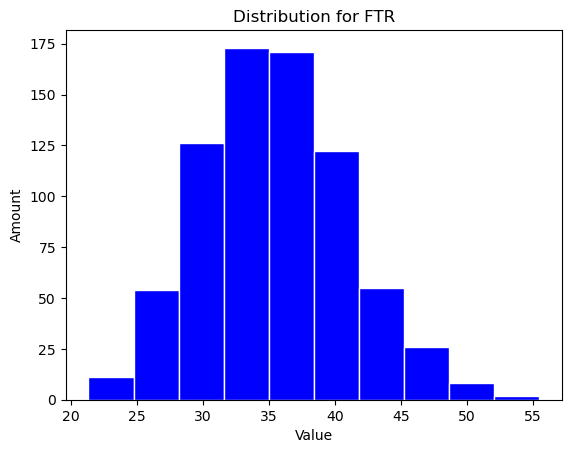

In [24]:
func.makeHist(marchMadnessDF, "FTR")
# FTR : Free Throw Rate (How often the given team shoots Free Throws)

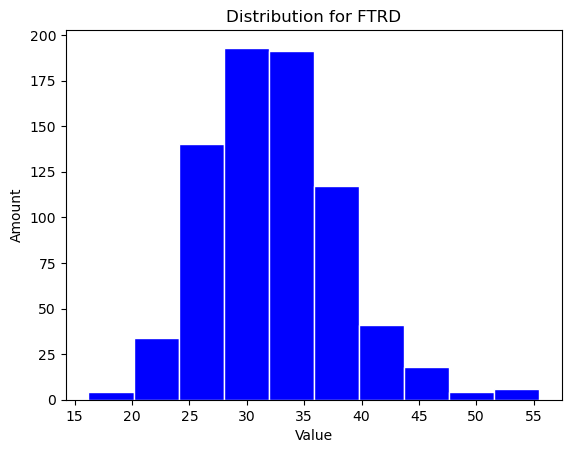

In [25]:
func.makeHist(marchMadnessDF, "FTRD")
# FTRD: Free Throw Rate Allowed

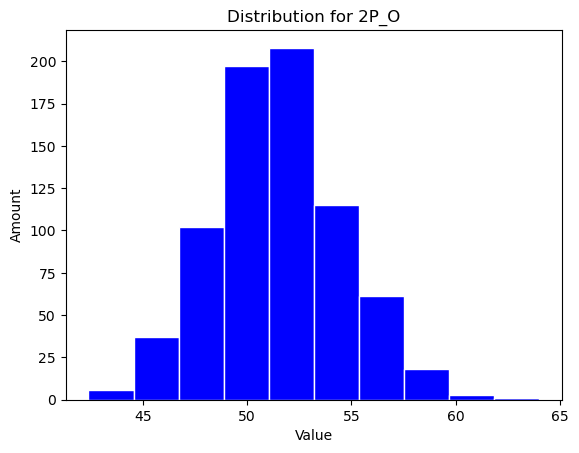

In [26]:
func.makeHist(marchMadnessDF, "2P_O")
# 2P_O: Two-Point Shooting Percentage

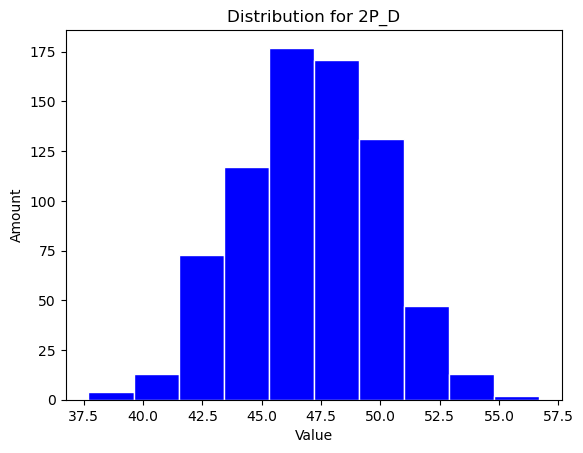

In [27]:
func.makeHist(marchMadnessDF, "2P_D")
# 2P_D: Two-Point Shooting Percentage Allowed

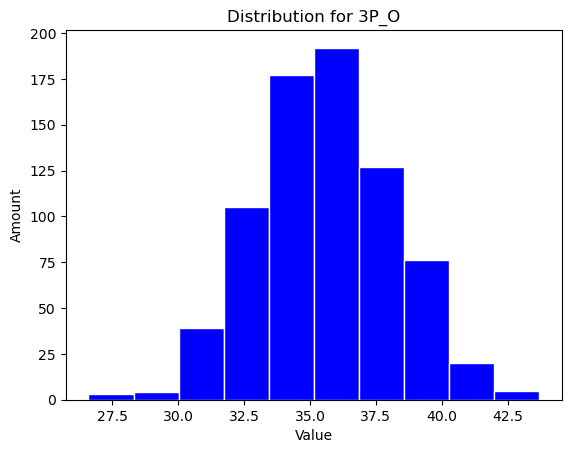

In [28]:
func.makeHist(marchMadnessDF, "3P_O")
# 3P_O: Three-Point Shooting Percentage

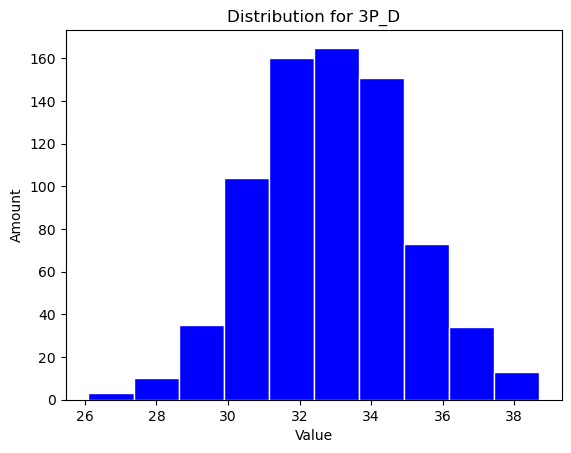

In [29]:
func.makeHist(marchMadnessDF, "3P_D")
# 3P_D: Three-Point Shooting Percentage Allowed

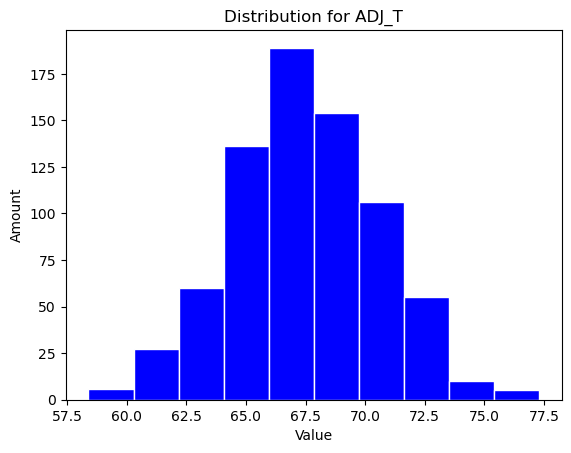

In [30]:
func.makeHist(marchMadnessDF, "ADJ_T")
# ADJ_T: Adjusted Tempo (An estimate of the tempo (possessions per 40 minutes) 
# a team would have against the team that wants to play at an average Division I tempo)

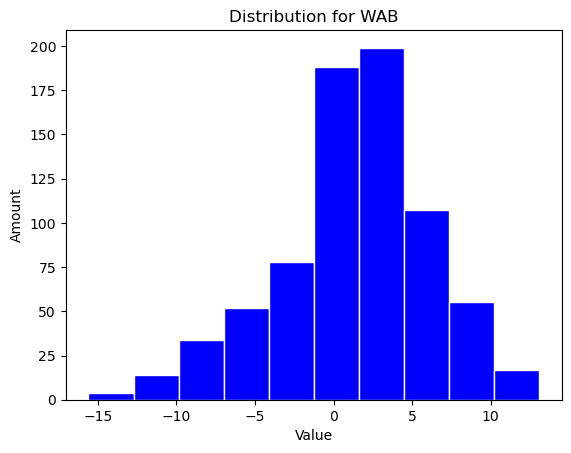

In [31]:
func.makeHist(marchMadnessDF, "WAB")
# WAB: Wins Above Bubble (The bubble refers to the cut off between making the NCAA March Madness Tournament and not making it)

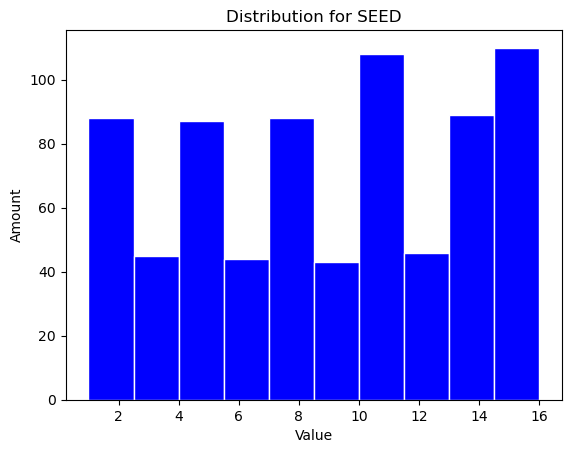

In [32]:
func.makeHist(marchMadnessDF, "SEED")
# SEED: Seed in the NCAA March Madness Tournament

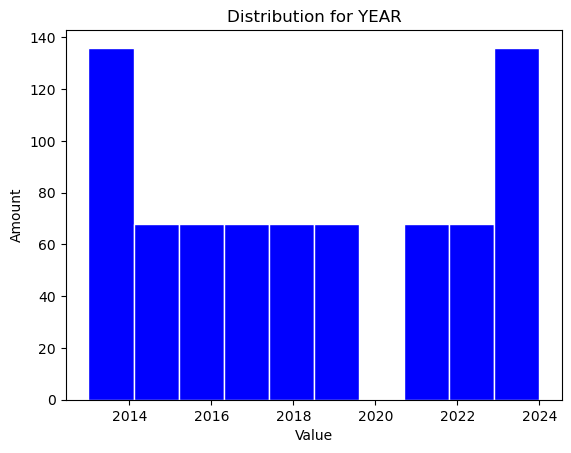

In [33]:
func.makeHist(marchMadnessDF, "YEAR")
# YEAR: Season

In [34]:
categoricalCol = ["CONF", "POSTSEASON"]
marchMadnessDF.head()

,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,18.2,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,15.8,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,19.5,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,22.8,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,17.1,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017


ENCODING CATEGORICALS

- CONF use label encoding because you can order the names of the conferences alphabetically.

- POSTSEASON use label encoding because you can order from 0-7 how a team finishes in the NCAA tournament.

POSTSEASON encoding

In [35]:
def getLabelList (n):
    labelList = []
    for i in range (n):
        labelList.append(i)
    return labelList

In [36]:
postseasonList = ["R68", "R64", "R32", "S16", "E8", "F4", "2ND", "Champions"]

In [37]:
confernenceList = ["AE", "Amer", "ASun", "A10", "ACC", "B12", "BE", "BSky", "BSth", "B10", "BW", "CAA", "CUSA", "Horz", "ind", "Ivy",  
                   "MAAC", "MAC", "MEAC", "MVC", "MWC", "NEC", "OVC", "P12", "Pat", "SEC", "SC", "Slnd", "SWAC", "Sum", "SB", "WCC", "WAC"]

In [38]:
masterDF["CONF"].unique()

array(['ACC', 'B10', 'B12', 'WCC', 'SEC', 'BE', 'Amer', 'P12', 'A10',
       'MVC', 'AE', 'ASun', 'BSky', 'BSth', 'BW', 'CAA', 'CUSA', 'Horz',
       'Ind', 'Ivy', 'MAAC', 'MAC', 'MEAC', 'MWC', 'NEC', 'OVC', 'Pat',
       'SB', 'SC', 'Slnd', 'Sum', 'SWAC', 'WAC', 'ind', 'GWC'],
      dtype=object)

In [39]:
marchMadnessDF["POSTSEASON"] = marchMadnessDF["POSTSEASON"].replace(postseasonList, getLabelList (len (postseasonList)))

/var/folders/1s/kscx9_5x0wddw_b3m_t57ysh0000gn/T/ipykernel_69514/1990343343.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  marchMadnessDF["POSTSEASON"] = marchMadnessDF["POSTSEASON"].replace(postseasonList, getLabelList (len (postseasonList)))


In [40]:
marchMadnessDF["CONF"] = marchMadnessDF["CONF"].replace(confernenceList, getLabelList (len (confernenceList)))

/var/folders/1s/kscx9_5x0wddw_b3m_t57ysh0000gn/T/ipykernel_69514/1164604946.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  marchMadnessDF["CONF"] = marchMadnessDF["CONF"].replace(confernenceList, getLabelList (len (confernenceList)))


In [41]:
marchMadnessDF.head()

,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,4,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,18.2,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,6,1.0,2016
1,9,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,15.8,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,6,1.0,2015
2,9,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,19.5,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,6,3.0,2018
3,5,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,22.8,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,6,3.0,2019
4,31,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,17.1,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,6,1.0,2017


SPLITTING TRAINING AND TEST SET

In [42]:
xDF = marchMadnessDF.drop('POSTSEASON', axis=1)
yDF = marchMadnessDF[['POSTSEASON']]
xDF.head()

,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
0,4,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,18.2,...,32.3,30.4,53.9,44.6,32.7,36.2,71.7,8.6,1.0,2016
1,9,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,15.8,...,36.2,22.4,54.8,44.7,36.5,37.5,59.3,11.3,1.0,2015
2,9,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,19.5,...,30.7,30.0,54.7,46.8,35.2,33.2,65.9,6.9,3.0,2018
3,5,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,22.8,...,32.9,36.6,52.8,41.9,36.5,29.7,67.5,7.0,3.0,2019
4,31,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,17.1,...,39.0,26.9,56.3,40.0,38.2,29.0,71.5,7.7,1.0,2017


In [43]:
yDF.head()

,POSTSEASON
0,6
1,6
2,6
3,6
4,6


In [44]:
from sklearn.model_selection import train_test_split

xTrain, xTest, yTrain, yTest = train_test_split(xDF, 
                                                yDF, 
                                                test_size=0.3)

In [45]:
xTrain.head()

,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
634,5,35,22,111.7,94.6,0.8704,50.0,48.1,16.7,21.6,...,34.1,30.1,51.5,49.2,31.0,30.8,69.7,2.2,6.0,2023
204,9,32,24,113.4,97.9,0.8448,52.4,47.5,19.0,18.0,...,38.5,32.6,51.0,45.6,36.3,34.2,68.6,3.7,6.0,2017
708,9,33,23,115.7,95.6,0.8999,53.2,46.3,15.9,16.4,...,32.4,27.7,52.8,45.2,35.8,31.9,68.7,2.4,8.0,2024
425,4,37,23,106.0,92.1,0.8344,46.9,46.2,19.1,19.5,...,40.5,31.4,46.6,45.1,31.7,31.8,64.0,-0.4,11.0,2018
565,25,34,22,106.3,89.6,0.8766,49.4,45.1,20.7,25.1,...,33.4,37.8,50.4,47.6,31.6,28.2,68.7,2.3,6.0,2022


In [46]:
yTrain.head()

,POSTSEASON
634,2
204,1
708,1
425,3
565,1


DATA STANDARDIZATION/NORMALIZATION

- Choosing standardization because the majority of the numerical variables follow a normal distribution

In [47]:
from sklearn.preprocessing import StandardScaler

xScaler = StandardScaler()
#yScaler = StandardScaler()

xColNames = xTrain.columns.values.tolist()
#yColNames = yTrain.columns.values.tolist()

xTrain[xColNames] = xScaler.fit_transform(xTrain[xColNames])
#yTrain[yColNames] = yScaler.fit_transform(yTrain[yColNames])

# Do transform on the testing to, already trained, needs to be applied to the test
xTest[xColNames] = xScaler.transform(xTest[xColNames])
#yTest[yColNames] = yScaler.transform(yTest[yColNames])

xTrain.head()

,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
634,-0.913153,0.514065,-0.456191,-0.002468,-0.429173,0.438144,-0.854896,0.097942,-0.344218,1.205665,...,-0.241357,-0.364835,-0.035622,0.708423,-1.811405,-0.991422,0.706528,0.171570,-0.604268,1.315033
204,-0.489392,-0.320891,0.007988,0.268450,0.194583,0.281658,0.048358,-0.159032,0.849726,-0.328033,...,0.559176,0.080480,-0.201370,-0.532339,0.259039,0.656654,0.335191,0.495805,-0.604268,-0.362436
708,-0.489392,-0.042573,-0.224102,0.634987,-0.240156,0.618469,0.349442,-0.672980,-0.759503,-1.009676,...,-0.550653,-0.792337,0.395323,-0.670201,0.063714,-0.458221,0.368949,0.214801,-0.166247,1.594611
425,-1.019093,1.070702,-0.224102,-0.910842,-0.901716,0.218086,-2.021599,-0.715809,0.901637,0.311008,...,0.923055,-0.133271,-1.659952,-0.704667,-1.537950,-0.506694,-1.217673,-0.390438,0.490785,-0.082858
565,1.205653,0.235746,-0.456191,-0.863033,-1.374258,0.476043,-1.080709,-1.186928,1.732207,2.696759,...,-0.368714,1.006736,-0.400267,0.156973,-1.577015,-2.251716,0.368949,0.193186,-0.604268,1.035455


MACHINE LEARNING


USE CLASSIFICATION based models

Logistic Regression, XGBoost, Random Forest

In [48]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

- Gradient Boosting 

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=7)
gbmodel = model.fit(xTrain, yTrain.values.ravel())
preds = gbmodel.predict(xTest)
print(precision_score(yTest, preds, average='macro'))
print(recall_score(yTest, preds, average='macro'))
print(f1_score(yTest, preds, average='macro'))
#print(accuracy_score(yTest, preds))

0.3111232827696242
0.2607202982202982
0.2740087677487379


- Random Foresting

In [50]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight="balanced").fit(xTrain, yTrain)
preds = model.predict(xTest)
print(precision_score(yTest, preds, average='macro'))
print(recall_score(yTest, preds, average='macro'))
print(f1_score(yTest, preds, average='macro'))
print(accuracy_score (yTest, preds))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.33570795339412357
0.25095448532948533
0.26293191546281436
0.5377777777777778


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


- Decision Tree

In [51]:
from sklearn import tree
dtmodel = tree.DecisionTreeClassifier(class_weight="balanced").fit(xTrain, yTrain)
preds = dtmodel.predict(xTest)
print(precision_score(yTest, preds, average='macro'))
print(recall_score(yTest, preds, average='macro'))
print(f1_score(yTest, preds, average='macro'))
print(accuracy_score (yTest, preds))

0.3225047557143861
0.3031896344396344
0.30314300658228555
0.4488888888888889


- Logistic Regression

In [52]:
from sklearn. linear_model import LogisticRegression
logregmodel = LogisticRegression().fit(xTrain, yTrain)
preds = logregmodel.predict(xTest)
print(precision_score(yTest, preds, average='macro'))
print(recall_score(yTest, preds, average='macro'))
print(f1_score(yTest, preds, average='macro'))
print(accuracy_score (yTest, preds))

0.1816928991464338
0.19038299663299663
0.18404791332971787
0.4577777777777778


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


- How did each model perform? Which performed the best?

    - All of my models did not perform great, but model evaluation should consider how hard it is to classify March Madness teams by their outcome in the tournament. F1 score balances how many positive and negative predicions (precision adn recall) we made correctly. Logistic regression and random forest model had the lowest F1 scores of the four models (0.1840 adn 0.2629 respectively). Gradient boosting and decision tree performed slightly better, but not by much having F1 scores of 0.2740 and 0.3031 respectively. Random forest was the only model with an accuracy above 50% at 53.77%. Random Forest also had the higest precison at 0.3357. Decision tree had the highest recall and F1 score. I would argue Random Forest was the best model because it had the highest accuracy and precision. In trying to classify which teams go far in March Madness, we care more about positive outcomes of the model predicts more than negative outcomes the model predicts. The Random Forest is also the only model where it's accurate at a rate slightly more than a coin flip. We ideally want to classify how far teams advance, not which teams don't advance.


- Did any models seem to have a relatively high amount of bias (underfitting)? Variance (overfitting)?

    - All our models have a little bias in that they are partial datasets, they only include teams that made March Madness, not all college basketball teams. Since the dataset includes data for every game played in a college basketball season, this includes games that teams played against non-tournament teams. All of our models seem to underfit our data because of how poorly they peformed. They all had precision, recall, and F1 scores between 0.25 and 0.50, indicating that our models did't understand the underlying pattern of the data, as they predicted teams either correctly or incorrectly advancing to a particular round in March Madness only 25-50% of the time. The dataset itself had a lot of variance. You have outlier teams that are bad metric wise with respect to other March Madness teams like the St.Peter's team that made the Elite Eight in 2022 and a great Purdue team in 2023 that lost in the first round all in the same dataset. There is a decent amount of variance in tourament outcomes that aren't always dependent on the strength of the team, making it harder for our models to understand the underlying patterns in the data. 